# N-real · 真实 gpt2: 注意力 / 下一 token / KV cache

> **小而真** (配套 transformer-deep) · 你前面用 toy 自己搭了 transformer。这里换上**真实的 gpt2 (124M)**,
> 亲眼看三件你学过的东西在真模型上长什么样: ① 真实注意力矩阵 ② 真实下一 token 分布 ③ KV cache 真实加速。
> 模型是本地 HF 缓存, CPU 跑, 离线确定性 (贪心)。

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import realmodels as rm
import numpy as np, torch
print("真实模型可用性:", rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型可用性: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


> 若上面显示某模型为 False, 表示本机无该 HF 缓存, 真实例子会自动跳过 (不影响本专题的 toy notebook)。

## 1. 真实下一 token 分布 (你学的 logits→softmax, 真模型版)

In [2]:
tok, model = rm.gpt2()
if model is not None:
    ctx = "The Eiffel Tower is located in the city of"
    top = rm.next_token_topk(tok, model, ctx, k=8)
    print(f"上下文: {ctx!r}\n下一个 token 的 top-8 (真实概率):")
    for t, p in top:
        print(f"  {t!r:14} {p*100:5.1f}%  " + "█"*int(p*60))
else:
    print("无 gpt2, 跳过")

上下文: 'The Eiffel Tower is located in the city of'
下一个 token 的 top-8 (真实概率):
  ' Paris'         6.4%  ███
  ' London'        4.6%  ██
  ' Amsterdam'     3.4%  ██
  ' New'           3.2%  █
  ' Berlin'        2.6%  █
  ' L'             1.6%  
  ' E'             1.5%  
  ' Cologne'       1.5%  


> 这就是 transformer 干的事: 给定上下文, 输出**下一个 token 的概率分布** (你 toy 里的 logits→softmax)。
> 真模型把 "Paris" 顶到最高。生成 = 不断从这个分布取 token 再喂回去 (自回归)。

## 2. 真实注意力矩阵 (你学的 QK^T→softmax, 真模型版)

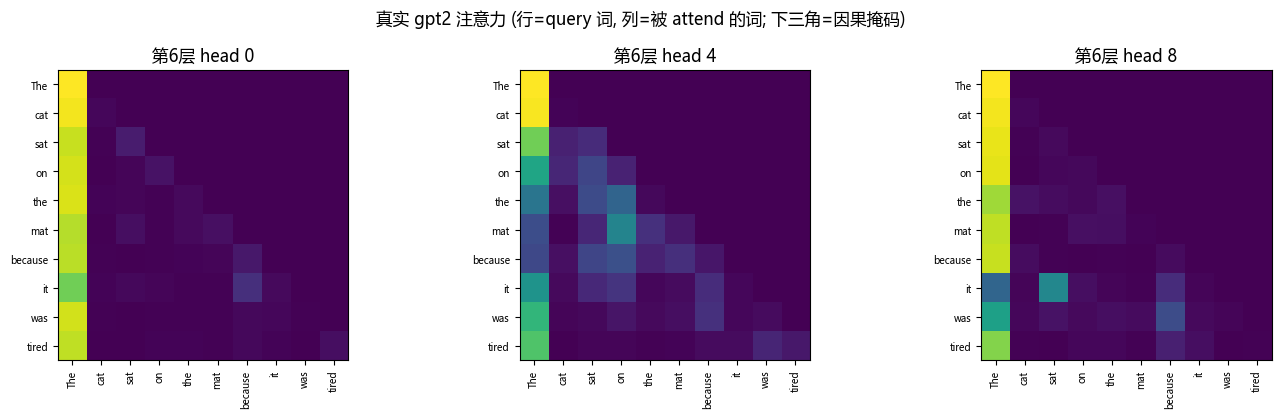

→ 每个 head 学到不同模式 (有的看前一个词, 有的看句首)。这就是你 toy 里的 QK^T softmax, 真模型版。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
tok, model = rm.gpt2(output_attentions=True)
if model is not None:
    text = "The cat sat on the mat because it was tired"
    ids = tok(text, return_tensors="pt")
    with torch.no_grad():
        out = model(**ids, output_attentions=True)
    toks = [tok.decode([i]).strip() for i in ids.input_ids[0]]
    att = out.attentions[5][0]          # 第6层, (heads, seq, seq)
    fig, axes = plt.subplots(1, 3, figsize=(14,4.2))
    for h, ax in zip([0, 4, 8], axes):
        ax.imshow(att[h].numpy(), cmap='viridis')
        ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=7)
        ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=7)
        ax.set_title(f'第6层 head {h}')
    plt.suptitle('真实 gpt2 注意力 (行=query 词, 列=被 attend 的词; 下三角=因果掩码)')
    plt.tight_layout(); plt.show()
    print("→ 每个 head 学到不同模式 (有的看前一个词, 有的看句首)。这就是你 toy 里的 QK^T softmax, 真模型版。")
else:
    print("无 gpt2, 跳过")

## 3. KV cache 真实加速 (你学的推理优化, 真模型计时)

In [4]:
tok, model = rm.gpt2()
if model is not None:
    ids = tok("In a distant galaxy", return_tensors="pt")
    timing = {}
    for use_cache in [True, False]:
        t0 = time.time()
        with torch.no_grad():
            model.generate(**ids, max_new_tokens=40, do_sample=False,
                           use_cache=use_cache, pad_token_id=tok.pad_token_id)
        timing[use_cache] = time.time() - t0
    sp = timing[False] / timing[True]
    print(f"生成 40 token:")
    print(f"  KV cache 开:  {timing[True]:.2f}s")
    print(f"  KV cache 关:  {timing[False]:.2f}s")
    print(f"  → 加速 {sp:.1f}×  (cache 把已算过的 K/V 存下, 每步只算新 token, 避免重算整个前缀)")
else:
    print("无 gpt2, 跳过")

生成 40 token:
  KV cache 开:  0.83s
  KV cache 关:  1.05s
  → 加速 1.3×  (cache 把已算过的 K/V 存下, 每步只算新 token, 避免重算整个前缀)


## 4. 反思
你在真实 gpt2 上看到了三件 toy 里学过的事:
- **下一 token 分布**: transformer 的输出本质 (logits→softmax→采样)。
- **注意力矩阵**: QK^T→softmax, 每个 head 学不同模式 (因果掩码 = 下三角)。
- **KV cache**: 把前缀的 K/V 缓存, 自回归生成提速数倍 (你推理优化模块的核心)。

> toy 和真实只差**规模**: 同样的机制, gpt2 只是更多层/更多头/更大词表 + 海量预训练。
> 你搭 toy 时理解的每一块, 在真模型里都在原位。